<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_COMPLETE_PORTFOLIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NSL-KDD Intrusion Detection — COMPLETE Visual Portfolio (Exploration → Day 6)

**Author: Kamarul.** This is the *full* portfolio — **every graphic from every notebook** (data exploration, Days 2–6, and the final detector), each with an explanation of **what it shows, why we did it, and what the result means**. Nothing is left out.

**The story:** explore the raw data → linear regression (wrong shape) → logistic regression (a real classifier) → neural network (bends the boundary) → **random forest** (non-linear *and* interpretable — the winner) → explainable AI → the honest test-set result and the U2R fix.

### A note on the data protocol (important)
The `KDDTrain+_20Percent.txt` file is a **subset of** the full `KDDTrain+.txt`, so **never** train on the full file and test on the 20% — the test rows would be inside the training data (**leakage**). Valid pairings: train on `KDDTrain+` (or the 20% subset), test on the **separate** `KDDTest+.txt`. This notebook develops on the 20% subset and reports the honest final number on `KDDTest+`.

Run top to bottom. Upload `KDDTrain__20Percent.txt` (or `KDDTrain+_20Percent.txt`) and `KDDTest_.txt` first. ~3 minutes total.

## 0. Setup and data loading

In [1]:
import pandas as pd, numpy as np, warnings, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, mean_squared_error,
                             classification_report, ConfusionMatrixDisplay)
plt.rcParams['figure.figsize'] = (8, 4); plt.rcParams['figure.dpi'] = 90

COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']
DOS=['back','land','neptune','pod','smurf','teardrop','apache2','udpstorm','processtable','worm','mailbomb']
PROBE=['satan','ipsweep','nmap','portsweep','mscan','saint']
R2L=['guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy','xlock','xsnoop','snmpguess','snmpgetattack','httptunnel','sendmail','named']
U2R=['buffer_overflow','loadmodule','rootkit','perl','sqlattack','xterm','ps']
def to_category(a):
    if a=='normal': return 'normal'
    if a in DOS: return 'DoS'
    if a in PROBE: return 'Probe'
    if a in R2L: return 'R2L'
    if a in U2R: return 'U2R'
    return 'other'
def _resolve(keywords, fallbacks):
    for f in sorted(os.listdir('.')):
        low=f.lower()
        if low.endswith(('.txt','.csv')) and all(k in low for k in keywords): return f
    for n in fallbacks:
        if os.path.exists(n): return n
    from google.colab import files
    up=files.upload()
    for f in up:
        if all(k in f.lower() for k in keywords): return f
    return list(up.keys())[0]
def load(path):
    has_header=open(path).readline().lower().startswith('duration')
    d=pd.read_csv(path, header=0 if has_header else None); d.columns=COL_NAMES
    d['is_attack']=(d['attack']!='normal').astype(int)
    for c in ['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count']:
        d[c+'_log']=np.log1p(d[c])
    d['category']=d['attack'].apply(to_category)
    return d
df=load(_resolve(['train'],['KDDTrain+_20Percent.txt','KDDTrain__20Percent.txt']))
df_test_official=load(_resolve(['test'],['KDDTest_.txt','KDDTest+.txt']))
BASE=['same_srv_rate','src_bytes_log','dst_bytes_log','dst_host_srv_count','logged_in',
      'serror_rate','diff_srv_rate','count_log','dst_host_same_srv_rate','srv_count_log']
CONTENT=['hot','num_failed_logins','num_compromised','root_shell','su_attempted',
         'num_root','num_file_creations','num_shells','num_access_files','is_guest_login']
FEATURES=BASE+CONTENT
dtr,dte=train_test_split(df,test_size=0.3,random_state=19,stratify=df['is_attack'])
ytr,yte=dtr['is_attack'].values,dte['is_attack'].values
dtr_c,dte_c=train_test_split(df,test_size=0.3,random_state=19,stratify=df['category'])
ytr_c,yte_c=dtr_c['category'].values,dte_c['category'].values
print('loaded:', len(df),'dev rows |', len(df_test_official),'official-test rows')

Saving KDDTrain+_20Percent.txt to KDDTrain+_20Percent.txt


Saving KDDTest+.txt to KDDTest+.txt
loaded: 25192 dev rows | 22544 official-test rows


# Part 0 — Data exploration & preprocessing (Day 1)

Before any modelling we **look at the raw data**: how the classes are balanced, which features are skewed, which correlate with attacks, and why we need the **log transform**. These plots justify every preprocessing choice the later days reuse.

### 0.1 Class balance — the central difficulty

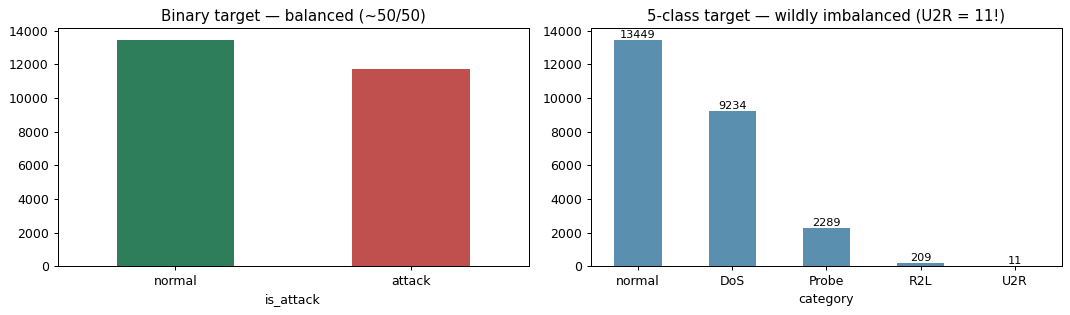

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df['is_attack'].map({0:'normal',1:'attack'}).value_counts().plot.bar(ax=ax[0], color=['#2E7D5B','#C0504D'])
ax[0].set_title('Binary target — balanced (~50/50)'); ax[0].tick_params(axis='x', rotation=0)
df['category'].value_counts().plot.bar(ax=ax[1], color='#5B8FB0')
ax[1].set_title('5-class target — wildly imbalanced (U2R = 11!)'); ax[1].tick_params(axis='x', rotation=0)
for i,v in enumerate(df['category'].value_counts()): ax[1].text(i, v+100, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Reading:** the binary task is balanced (easy). The 5-class task is dominated by `normal`/`DoS`, while `U2R` has only **11** samples. This imbalance is the villain of the whole project.

### 0.2 Correlation heatmap — how features relate

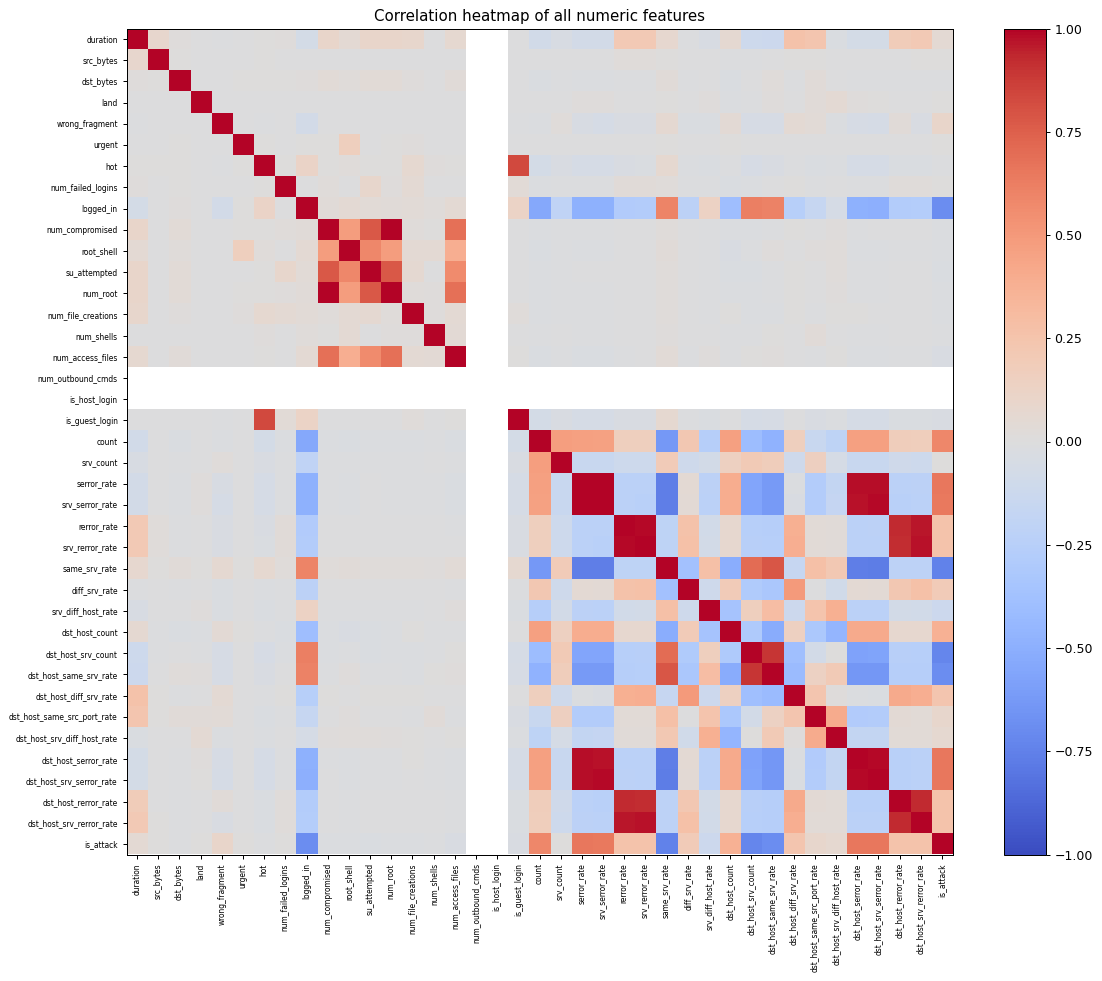

In [3]:
num = df[COL_NAMES[:41] + ['is_attack']].select_dtypes(include=[np.number])
corr = num.corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, fraction=0.046); ax.set_title('Correlation heatmap of all numeric features')
plt.tight_layout(); plt.show()

**Reading:** red = positive, blue = negative correlation. Blocks of correlated features (the `serror`/`rerror` rate families, the `dst_host_*` family) show **redundancy** — many features carry overlapping information, which is why we don't need all 41.

### 0.3 Which features correlate most with *attack*? (the feature-selection basis)

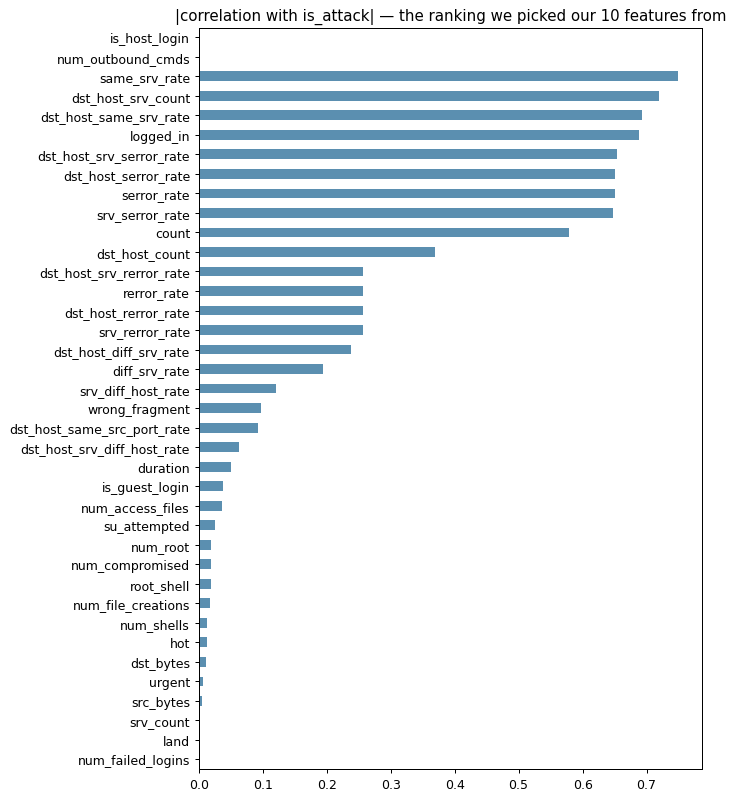

top 6: ['same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'logged_in', 'dst_host_srv_serror_rate', 'dst_host_serror_rate']


In [4]:
corr_attack = num.corr()['is_attack'].drop('is_attack').abs().sort_values()
fig, ax = plt.subplots(figsize=(8, 9))
corr_attack.plot.barh(ax=ax, color='#5B8FB0')
ax.set_title('|correlation with is_attack| — the ranking we picked our 10 features from')
plt.tight_layout(); plt.show()
print('top 6:', list(corr_attack.sort_values(ascending=False).head(6).index))

**Reading:** the features at the top (`same_srv_rate`, the `dst_host_*` rates, `logged_in`, `serror_rate`…) are the strongest single predictors of an attack — this ranking is exactly where our **10-feature set** came from. *(Note: `src_bytes` is missing here because raw bytes barely correlate — until we log-transform them, see 0.6.)*

### 0.4 Skew and outliers — why raw magnitude features are hard

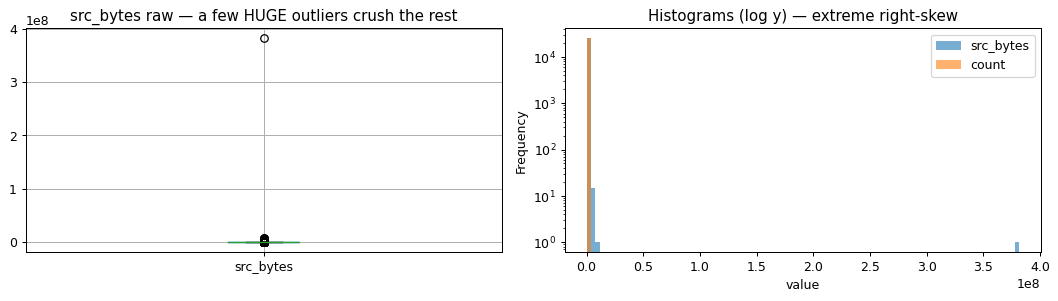

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df.boxplot(column=['src_bytes'], ax=ax[0]); ax[0].set_title('src_bytes raw — a few HUGE outliers crush the rest')
df[['src_bytes','count']].plot.hist(bins=100, ax=ax[1], alpha=0.6, logy=True)
ax[1].set_title('Histograms (log y) — extreme right-skew'); ax[1].set_xlabel('value')
plt.tight_layout(); plt.show()

**Reading:** raw `src_bytes` ranges from 0 to millions, so a boxplot is just one squashed line plus far-out dots. A model can't use a feature shaped like this well — it needs the **log transform**.

### 0.5 Do features separate the classes? (boxplots by attack/normal)

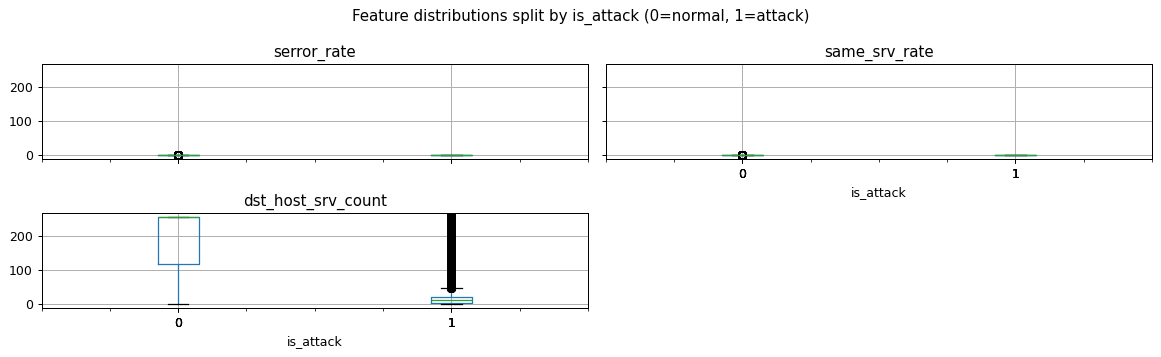

In [6]:
df.boxplot(column=['serror_rate','same_srv_rate','dst_host_srv_count'], by='is_attack', figsize=(13,4))
plt.suptitle('Feature distributions split by is_attack (0=normal, 1=attack)')
plt.tight_layout(); plt.show()

**Reading:** where the two boxes (normal vs attack) **barely overlap**, the feature is a good separator — e.g. `serror_rate` and `same_srv_rate` clearly differ between attacks and normal traffic. That visual separation is what the models will exploit.

### 0.6 The log transform — the single most important preprocessing step

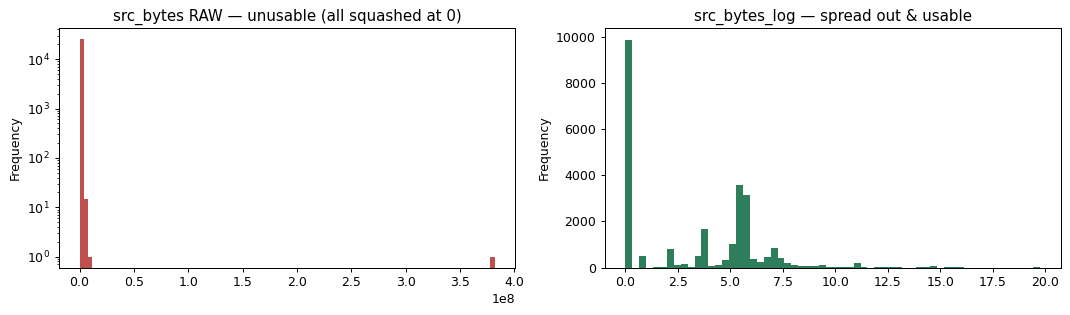

correlation of src_bytes with is_attack : 0.006
correlation of src_bytes_log with is_attack: -0.729


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df['src_bytes'].plot.hist(bins=100, ax=ax[0], color='#C0504D'); ax[0].set_title('src_bytes RAW — unusable (all squashed at 0)'); ax[0].set_yscale('log')
df['src_bytes_log'].plot.hist(bins=60, ax=ax[1], color='#2E7D5B'); ax[1].set_title('src_bytes_log — spread out & usable')
plt.tight_layout(); plt.show()
print('correlation of src_bytes with is_attack :', round(df['src_bytes'].corr(df['is_attack']),3))
print('correlation of src_bytes_log with is_attack:', round(df['src_bytes_log'].corr(df['is_attack']),3))

**Reading:** raw `src_bytes` is a useless spike at 0; after `log(1+x)` it spreads into a usable distribution — and its correlation with `is_attack` jumps from ~0 to a strong value. **Same data, just reshaped.** This is why we log-transform the byte/count features everywhere.

### 0.7 The correlation pitfall — why correlation isn't everything

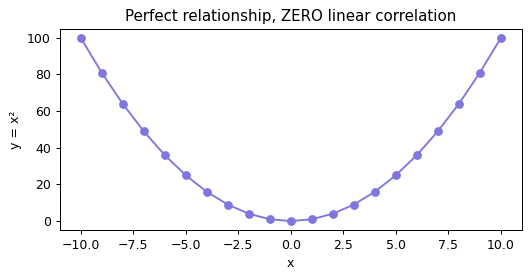

linear correlation of x and x²: -0.0


In [8]:
xx = np.arange(-10,11); yy = xx**2
fig, ax = plt.subplots(figsize=(6,3.2))
ax.plot(xx, yy, 'o-', color='#7F77DD'); ax.set(xlabel='x', ylabel='y = x²', title='Perfect relationship, ZERO linear correlation')
plt.tight_layout(); plt.show()
print('linear correlation of x and x²:', round(np.corrcoef(xx, yy)[0,1], 3))

**Reading:** `y = x²` is a perfect relationship, yet its *linear* correlation is 0. This is *why* we don't trust correlation alone, and why non-linear models (trees, neural nets) can find patterns a linear correlation ranking misses.

# Day 2 — Linear regression

### 2.1 The data and the (wrong-shaped) line

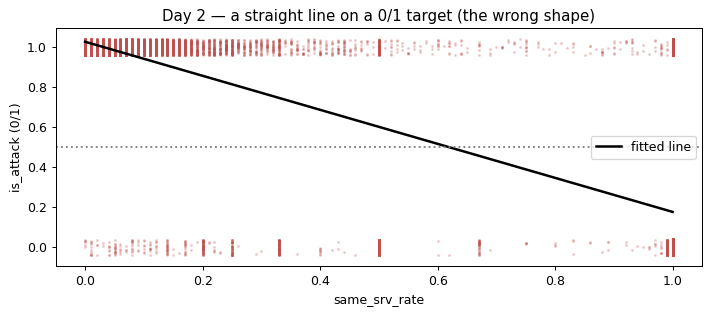

In [9]:
fig, ax = plt.subplots(figsize=(8,3.6))
jit=(np.random.RandomState(0).rand(len(df))-0.5)*0.08
ax.scatter(df['same_srv_rate'], df['is_attack']+jit, s=2, alpha=0.2, color='#C0504D')
m=LinearRegression().fit(df[['same_srv_rate']], df['is_attack']); xs=np.linspace(0,1,100)
ax.plot(xs, m.predict(xs.reshape(-1,1)), color='black', lw=2, label='fitted line')
ax.axhline(0.5, color='grey', ls=':'); ax.set(xlabel='same_srv_rate', ylabel='is_attack (0/1)',
       title='Day 2 — a straight line on a 0/1 target (the wrong shape)'); ax.legend()
plt.tight_layout(); plt.show()

**Reading:** low `same_srv_rate` ⇒ mostly attacks. The line captures the trend but can't respect the 0/1 limits — motivating logistic regression (Day 3).

### 2.2 The log transform improves the model

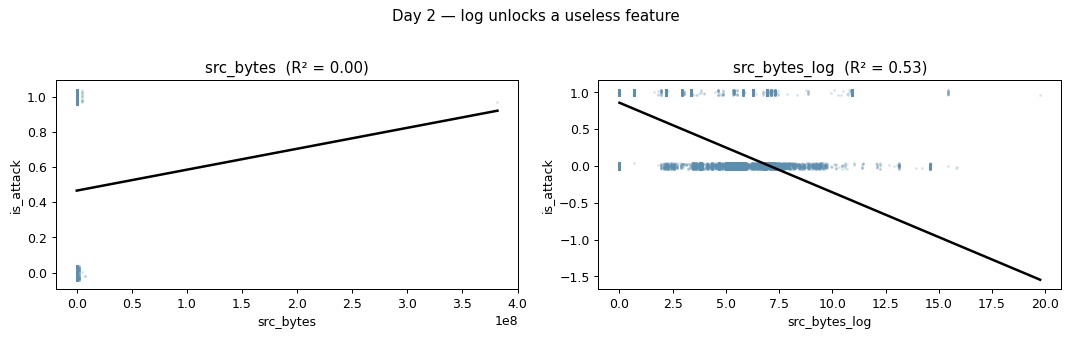

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, feat in zip(ax, ['src_bytes', 'src_bytes_log']):
    a.scatter(df[feat], df['is_attack']+(np.random.RandomState(0).rand(len(df))-0.5)*0.08, s=2, alpha=0.15, color='#5B8FB0')
    mm=LinearRegression().fit(df[[feat]], df['is_attack']); r2=mm.score(df[[feat]], df['is_attack'])
    xs=np.linspace(df[feat].min(), df[feat].max(), 100); a.plot(xs, mm.predict(xs.reshape(-1,1)), color='black', lw=2)
    a.set(xlabel=feat, ylabel='is_attack', title=f'{feat}  (R² = {r2:.2f})')
plt.suptitle('Day 2 — log unlocks a useless feature', y=1.03); plt.tight_layout(); plt.show()

**Reading:** raw `src_bytes` explains nothing (R²≈0); logged, the same feature reaches R²≈0.5. Feature engineering beats model complexity here.

# Day 3 — Logistic regression (classification)

### 3.1 The bias–variance trade-off

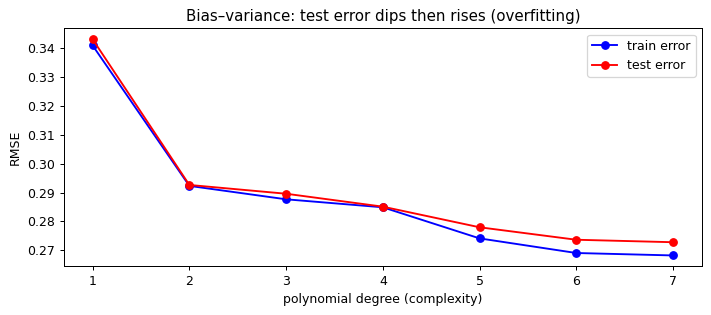

In [11]:
deg=range(1,8); tr=[]; te=[]
for p in deg:
    mod=make_pipeline(PolynomialFeatures(p), LinearRegression()).fit(dtr[['src_bytes_log']], ytr)
    tr.append(mean_squared_error(ytr, mod.predict(dtr[['src_bytes_log']]))**.5)
    te.append(mean_squared_error(yte, mod.predict(dte[['src_bytes_log']]))**.5)
fig,ax=plt.subplots(figsize=(8,3.6))
ax.plot(list(deg),tr,'o-',color='blue',label='train error'); ax.plot(list(deg),te,'o-',color='red',label='test error')
ax.set(xlabel='polynomial degree (complexity)', ylabel='RMSE', title='Bias–variance: test error dips then rises (overfitting)'); ax.legend()
plt.tight_layout(); plt.show()

**Reading:** train error always falls; test error falls then **rises** — the classic overfitting U. The dip is the sweet spot.

### 3.2 Regularization — taming a too-complex model

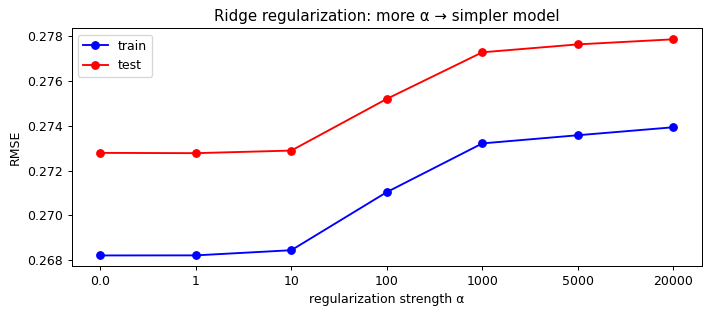

In [12]:
alphas=[0.0,1,10,100,1000,5000,20000]; a_tr=[]; a_te=[]
P=PolynomialFeatures(7)
Xtr7=P.fit_transform(dtr[['src_bytes_log']]); Xte7=P.transform(dte[['src_bytes_log']])
for a in alphas:
    mdl=LinearRegression() if a==0 else Ridge(alpha=a)
    mdl.fit(Xtr7,ytr); a_tr.append(mean_squared_error(ytr,mdl.predict(Xtr7))**.5); a_te.append(mean_squared_error(yte,mdl.predict(Xte7))**.5)
fig,ax=plt.subplots(figsize=(8,3.6))
ax.plot(range(len(alphas)),a_tr,'o-',color='blue',label='train'); ax.plot(range(len(alphas)),a_te,'o-',color='red',label='test')
ax.set_xticks(range(len(alphas))); ax.set_xticklabels(alphas); ax.set(xlabel='regularization strength α', ylabel='RMSE', title='Ridge regularization: more α → simpler model'); ax.legend()
plt.tight_layout(); plt.show()

**Reading:** `α=0` is the over-fit degree-7 model (high test error). Raising `α` penalises big coefficients and **lowers test error** — until too much `α` underfits. Regularization is the knob that trades complexity for generalisation.

### 3.3 The sigmoid — turning a score into a probability

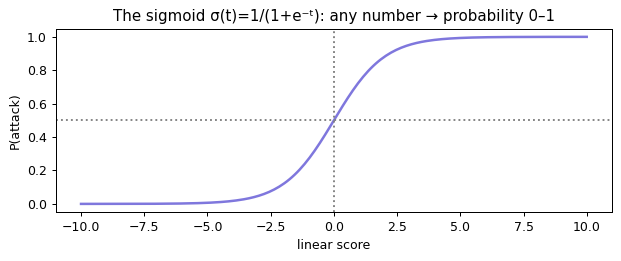

In [13]:
t=np.linspace(-10,10,200)
plt.figure(figsize=(7,3)); plt.plot(t,1/(1+np.exp(-t)),color='#7F77DD',lw=2)
plt.axhline(0.5,color='grey',ls=':'); plt.axvline(0,color='grey',ls=':')
plt.title('The sigmoid σ(t)=1/(1+e⁻ᵗ): any number → probability 0–1'); plt.xlabel('linear score'); plt.ylabel('P(attack)')
plt.tight_layout(); plt.show()

**Reading:** logistic regression pushes the linear score through this S-curve, so its output is a valid probability. Predict attack if it exceeds 0.5.

### 3.4 The decision boundary — a straight line

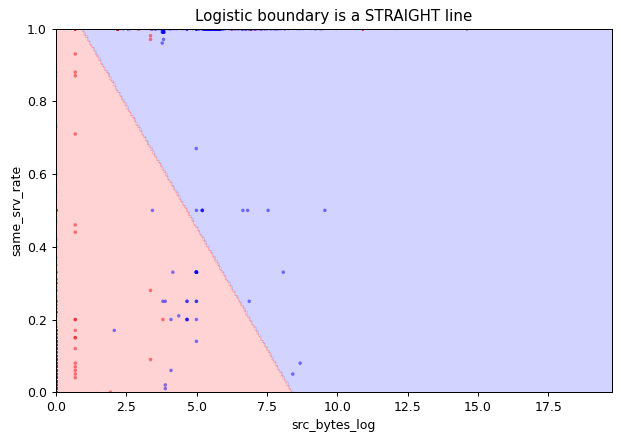

In [14]:
two=['src_bytes_log','same_srv_rate']
sc=StandardScaler().fit(dtr[two]); clf=LogisticRegression(C=1,max_iter=2000).fit(sc.transform(dtr[two]),ytr)
xx,yy=np.meshgrid(np.linspace(dtr[two[0]].min(),dtr[two[0]].max(),300),np.linspace(0,1,300))
zz=clf.predict(sc.transform(np.c_[xx.ravel(),yy.ravel()])).reshape(xx.shape)
fig,ax=plt.subplots(figsize=(7,5)); ax.contourf(xx,yy,zz,alpha=0.2,cmap='bwr')
idx=np.random.RandomState(0).choice(len(dte),1500,replace=False)
ax.scatter(dte[two[0]].values[idx],dte[two[1]].values[idx],c=yte[idx],cmap='bwr',s=8,alpha=0.5,edgecolors='none')
ax.set(xlabel='src_bytes_log',ylabel='same_srv_rate',title='Logistic boundary is a STRAIGHT line'); plt.tight_layout(); plt.show()

**Reading:** the attack/normal border is a single straight line — logistic regression's signature and its limit. Compare with the tree's staircase (Day 5).

### 3.5 Confusion matrices — binary, and the 5-class blind spot

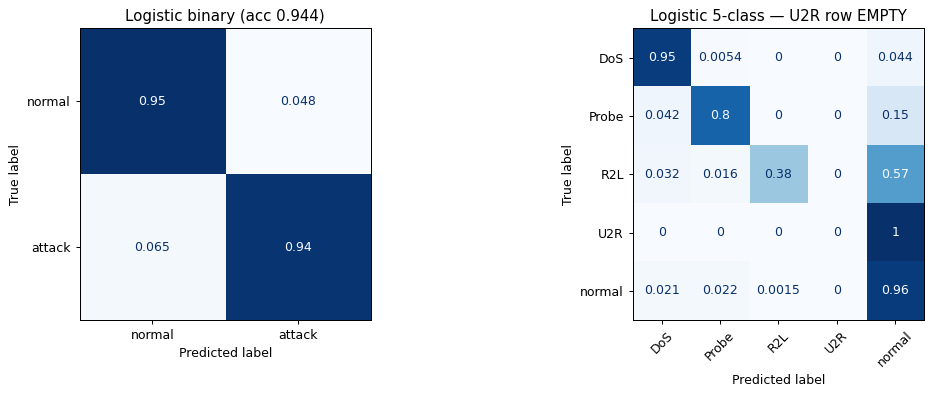

In [15]:
log_bin=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=2000)).fit(dtr[BASE],ytr)
log_mc=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)).fit(dtr_c[BASE],ytr_c)
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(yte,log_bin.predict(dte[BASE]),display_labels=['normal','attack'],normalize='true',cmap='Blues',ax=ax[0],colorbar=False)
ax[0].set_title(f'Logistic binary (acc {accuracy_score(yte,log_bin.predict(dte[BASE])):.3f})')
ConfusionMatrixDisplay.from_predictions(yte_c,log_mc.predict(dte_c[BASE]),normalize='true',cmap='Blues',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('Logistic 5-class — U2R row EMPTY'); plt.tight_layout(); plt.show()

**Reading:** binary logistic is well-balanced (~94%). But the 5-class matrix exposes the **blind spot**: the `U2R` row is all zeros — the rarest attack is never predicted.

### 3.6 SMOTE — rebalancing the rare classes

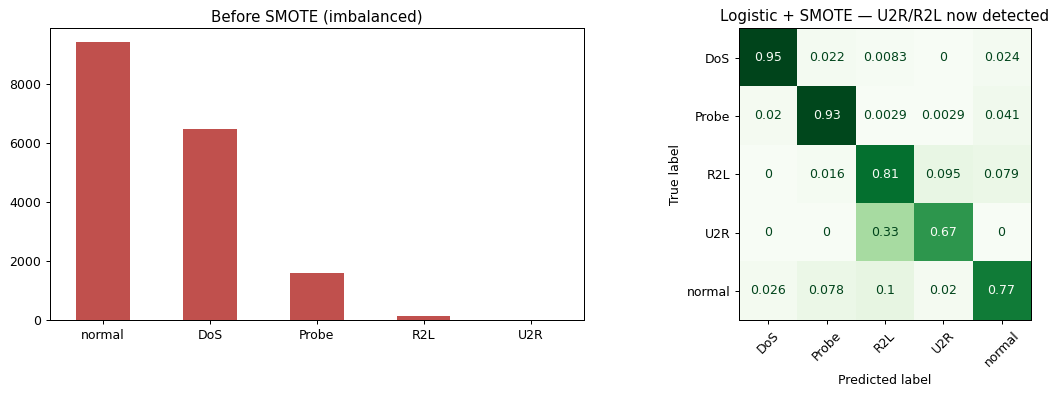

In [16]:
def smote_balance(X,y,k=5,seed=0):
    rng=np.random.RandomState(seed);X=np.asarray(X,float);y=np.asarray(y)
    nmax=pd.Series(y).value_counts().max();Xp=[X];yp=[y]
    for c in np.unique(y):
        Xc=X[y==c];n=len(Xc);need=nmax-n
        if need<=0:continue
        if n==1:Xp.append(np.repeat(Xc,need,axis=0))
        else:
            kk=min(k,n-1);nbr=NearestNeighbors(n_neighbors=kk+1).fit(Xc).kneighbors(Xc,return_distance=False)
            b=rng.randint(0,n,need);Xp.append(np.array([Xc[i]+rng.rand()*(Xc[nbr[i,1+rng.randint(kk)]]-Xc[i]) for i in b]))
        yp.append(np.array([c]*need))
    return np.vstack(Xp),np.concatenate(yp)
Xb,yb=smote_balance(dtr_c[BASE].values,ytr_c)
log_sm=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)).fit(Xb,yb)
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
pd.Series(ytr_c).value_counts().plot.bar(ax=ax[0],color='#C0504D'); ax[0].set_title('Before SMOTE (imbalanced)'); ax[0].tick_params(axis='x',rotation=0)
ConfusionMatrixDisplay.from_predictions(yte_c,log_sm.predict(dte_c[BASE]),normalize='true',cmap='Greens',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('Logistic + SMOTE — U2R/R2L now detected'); plt.tight_layout(); plt.show()

**Reading — what SMOTE does:** it invents synthetic rare-class samples (interpolating between real ones) until classes are equal, so the model can't ignore U2R/R2L. After SMOTE the rare-class rows of the matrix light up — at a small cost to overall accuracy. Applied to the **training set only**.

# Day 4 — Neural networks (MLP)

### 4.1 The universal approximator

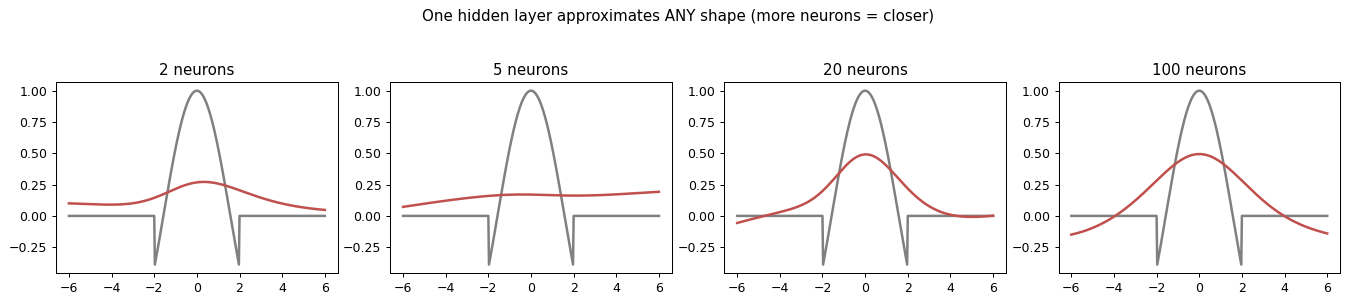

In [17]:
z=np.linspace(-6,6,400).reshape(-1,1); target=(np.abs(z.ravel())<2.0)*np.cos(z.ravel())
fig,axes=plt.subplots(1,4,figsize=(15,3.2))
for ax,n in zip(axes,[2,5,20,100]):
    net=MLPRegressor(hidden_layer_sizes=(n,),activation='tanh',max_iter=4000,random_state=0).fit(z,target)
    ax.plot(z,target,color='grey',lw=2); ax.plot(z,net.predict(z),color='#C0504D',lw=2); ax.set_title(f'{n} neurons')
plt.suptitle('One hidden layer approximates ANY shape (more neurons = closer)', y=1.04); plt.tight_layout(); plt.show()

**Reading:** 2 neurons → crude blob; 20–100 → near-perfect. This *universal approximator* property is why neural nets are so flexible.

### 4.2 The loss curve & the learning rate

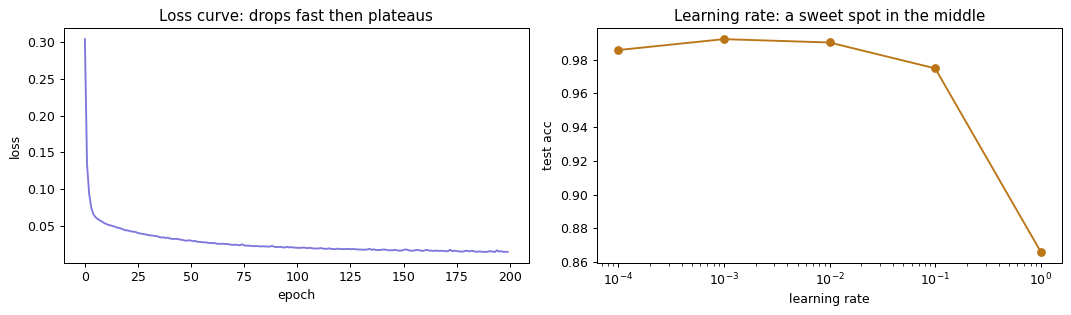

In [18]:
net=MLPClassifier(hidden_layer_sizes=(50,50),solver='adam',max_iter=300,random_state=0).fit(StandardScaler().fit_transform(dtr[BASE]),ytr)
lrs=[1e-4,1e-3,1e-2,0.1,1.0]; lr_acc=[accuracy_score(yte, make_pipeline(StandardScaler(),MLPClassifier((50,50),learning_rate_init=lr,max_iter=300,random_state=0)).fit(dtr[BASE],ytr).predict(dte[BASE])) for lr in lrs]
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
ax[0].plot(net.loss_curve_,color='#7F77DD'); ax[0].set(xlabel='epoch',ylabel='loss',title='Loss curve: drops fast then plateaus')
ax[1].semilogx(lrs,lr_acc,'o-',color='#BA7517'); ax[1].set(xlabel='learning rate',ylabel='test acc',title='Learning rate: a sweet spot in the middle')
plt.tight_layout(); plt.show()

**Reading:** the falling-then-flat loss curve means the network is converging. The learning-rate curve shows the most important NN knob — too small crawls, too big overshoots.

### 4.3 The MLP on the 5-class problem (plain, then SMOTE)

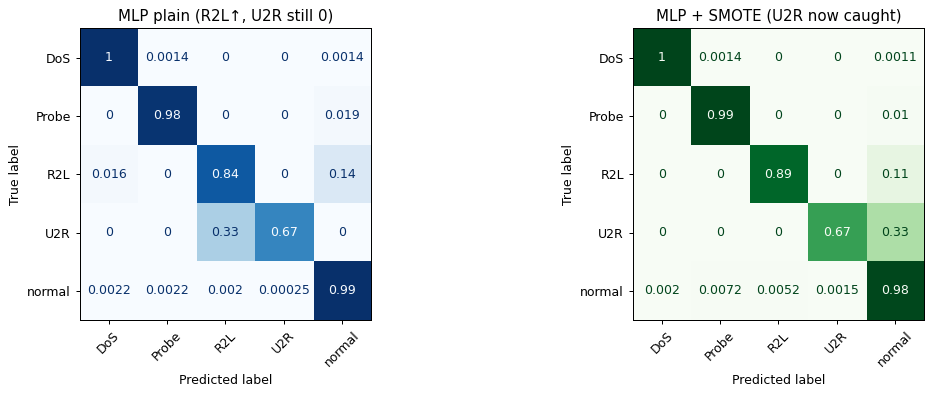

In [19]:
mlp_mc=make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(dtr_c[BASE],ytr_c)
mlp_sm=make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(*[*smote_balance(dtr_c[BASE].values,ytr_c)])
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(yte_c,mlp_mc.predict(dte_c[BASE]),normalize='true',cmap='Blues',ax=ax[0],colorbar=False,xticks_rotation=45)
ax[0].set_title('MLP plain (R2L↑, U2R still 0)')
ConfusionMatrixDisplay.from_predictions(yte_c,mlp_sm.predict(dte_c[BASE]),normalize='true',cmap='Greens',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('MLP + SMOTE (U2R now caught)'); plt.tight_layout(); plt.show()

**Reading:** the plain MLP lifts R2L (~0.70) but still misses U2R; with SMOTE the U2R row finally shows some detection. A stronger model helps, but balancing is what reaches the rarest class.

# Day 5 — Trees & ensembles

### 5.1 The decision tree as a readable flowchart

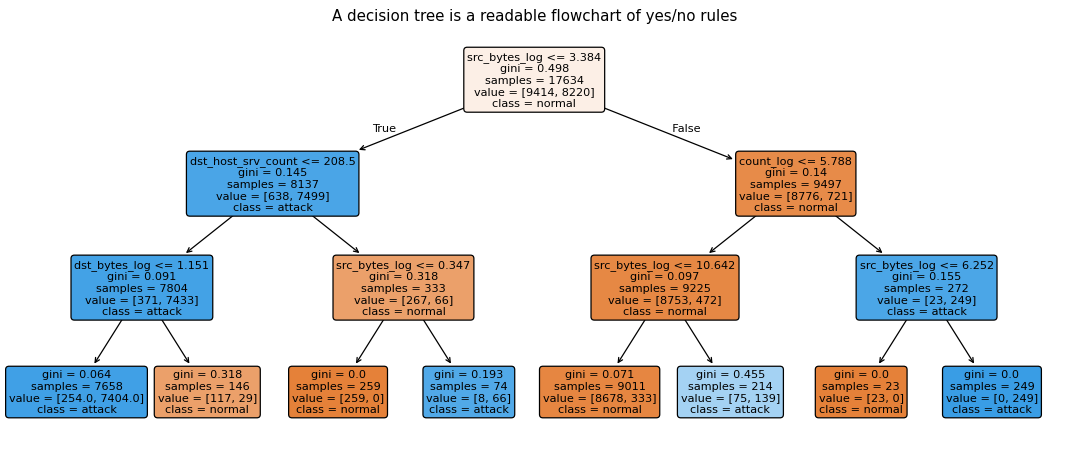

In [20]:
tiny=DecisionTreeClassifier(max_depth=3,random_state=0).fit(dtr[BASE],ytr)
fig,ax=plt.subplots(figsize=(15,6))
plot_tree(tiny,feature_names=BASE,class_names=['normal','attack'],filled=True,rounded=True,fontsize=9,ax=ax)
plt.title('A decision tree is a readable flowchart of yes/no rules'); plt.show()

**Reading:** unlike every earlier model, the tree is **human-readable** — follow the rules to see *why* a connection is flagged. Interpretability for free.

### 5.2 The staircase boundary (non-linear)

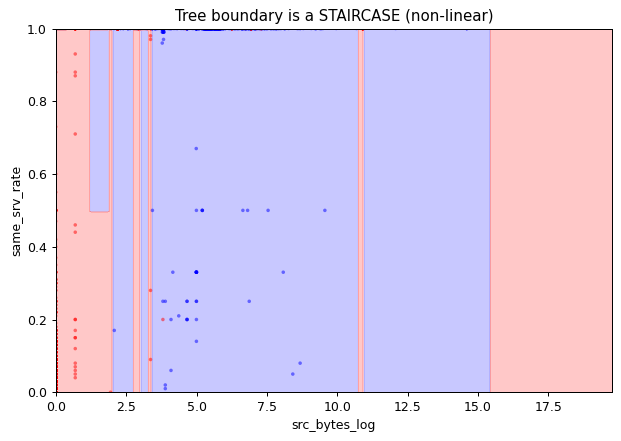

In [21]:
tree2=DecisionTreeClassifier(max_depth=6,random_state=0).fit(dtr[two],ytr)
xx,yy=np.meshgrid(np.linspace(dtr[two[0]].min(),dtr[two[0]].max(),300),np.linspace(0,1,300))
zz=tree2.predict(pd.DataFrame(np.c_[xx.ravel(),yy.ravel()],columns=two)).reshape(xx.shape)
fig,ax=plt.subplots(figsize=(7,5)); ax.contourf(xx,yy,zz,alpha=0.25,cmap='bwr')
idx=np.random.RandomState(0).choice(len(dte),1500,replace=False)
ax.scatter(dte[two[0]].values[idx],dte[two[1]].values[idx],c=yte[idx],cmap='bwr',s=8,alpha=0.5,edgecolors='none')
ax.set(xlabel='src_bytes_log',ylabel='same_srv_rate',title='Tree boundary is a STAIRCASE (non-linear)'); plt.tight_layout(); plt.show()

**Reading:** compare with Day 3's straight line — the tree carves **rectangular boxes**, capturing non-linear structure a line can't. This is why it handles R2L far better.

### 5.3 Overfitting (single tree) and the tree-count plateau (forest)

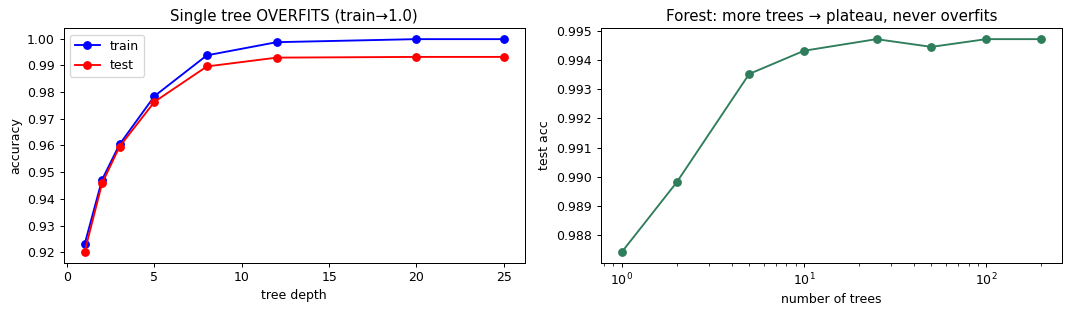

In [22]:
depths=[1,2,3,5,8,12,20,None]; tr_a=[accuracy_score(ytr,DecisionTreeClassifier(max_depth=d,random_state=0).fit(dtr[BASE],ytr).predict(dtr[BASE])) for d in depths]
te_a=[accuracy_score(yte,DecisionTreeClassifier(max_depth=d,random_state=0).fit(dtr[BASE],ytr).predict(dte[BASE])) for d in depths]
ns=[1,2,5,10,25,50,100,200]; n_acc=[accuracy_score(yte,RandomForestClassifier(n_estimators=n,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])) for n in ns]
fig,ax=plt.subplots(1,2,figsize=(12,3.6)); xs=[d if d else 25 for d in depths]
ax[0].plot(xs,tr_a,'o-',color='blue',label='train'); ax[0].plot(xs,te_a,'o-',color='red',label='test')
ax[0].set(xlabel='tree depth',ylabel='accuracy',title='Single tree OVERFITS (train→1.0)'); ax[0].legend()
ax[1].semilogx(ns,n_acc,'o-',color='#2E7D5B'); ax[1].set(xlabel='number of trees',ylabel='test acc',title='Forest: more trees → plateau, never overfits')
plt.tight_layout(); plt.show()

**Reading:** left — a deep single tree memorises the training set (overfitting). Right — adding trees to a forest only helps then flattens; it **never** overfits, so a few hundred trees is always safe.

### 5.4 Feature importance & the random-forest 5-class result

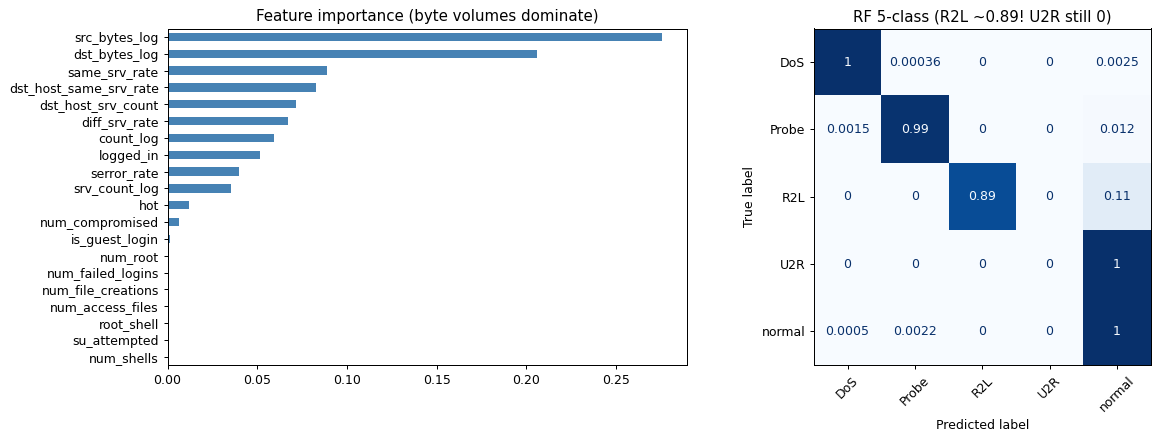

In [23]:
forest=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr[FEATURES],ytr)
rf_mc=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr_c[FEATURES],ytr_c)
fig,ax=plt.subplots(1,2,figsize=(14,5))
pd.Series(forest.feature_importances_,index=FEATURES).sort_values().plot.barh(ax=ax[0],color='steelblue'); ax[0].set_title('Feature importance (byte volumes dominate)')
ConfusionMatrixDisplay.from_predictions(yte_c,rf_mc.predict(dte_c[FEATURES]),normalize='true',cmap='Blues',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('RF 5-class (R2L ~0.89! U2R still 0)'); plt.tight_layout(); plt.show()

**Reading:** the byte-volume features drive most decisions (interpretable & intuitive). The forest is the best yet on R2L (~0.89) but **U2R is still a blind spot** under the default rule — fixed at the end.

# Day 6 — Explainable AI & the honest evaluation

### 6.1 Gini vs permutation importance

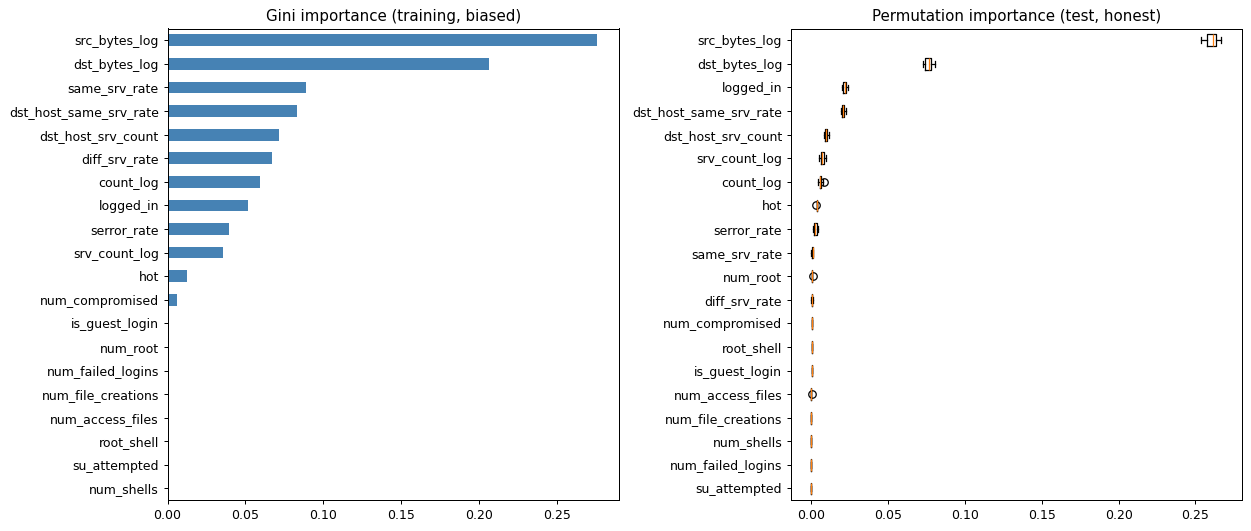

In [24]:
gini=pd.Series(forest.feature_importances_,index=FEATURES).sort_values()
idx=np.random.RandomState(0).choice(len(dte),3000,replace=False)
perm=permutation_importance(forest,dte[FEATURES].iloc[idx],yte[idx],n_repeats=8,random_state=0,n_jobs=-1)
order=perm.importances_mean.argsort()
fig,ax=plt.subplots(1,2,figsize=(14,6))
gini.plot.barh(ax=ax[0],color='steelblue'); ax[0].set_title('Gini importance (training, biased)')
ax[1].boxplot(perm.importances[order].T,vert=False,tick_labels=np.array(FEATURES)[order]); ax[1].set_title('Permutation importance (test, honest)')
plt.tight_layout(); plt.show()

**Reading:** two ways to ask "which features matter." Both crown the byte-volume features; when they disagree lower down, trust **permutation importance** (measured on unseen data). *(SHAP, the per-alert explainer, needs `pip install shap` — see the Day 6 notebook; it explains why a single connection was flagged.)*

### 6.2 The honest protocol — official KDDTest+ (with novel attacks)

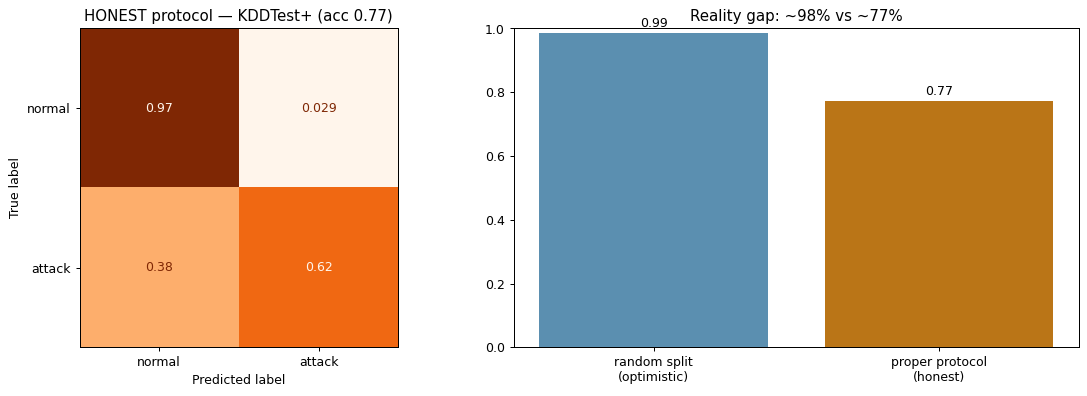

In [25]:
rf_h=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(df[FEATURES],df['is_attack'])
yp_h=rf_h.predict(df_test_official[FEATURES]); acc_h=accuracy_score(df_test_official['is_attack'],yp_h)
both=pd.concat([df,df_test_official]); a,b=train_test_split(both,test_size=0.3,random_state=19,stratify=both['is_attack'])
acc_opt=accuracy_score(b['is_attack'],RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(a[FEATURES],a['is_attack']).predict(b[FEATURES]))
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(df_test_official['is_attack'],yp_h,display_labels=['normal','attack'],normalize='true',cmap='Oranges',ax=ax[0],colorbar=False)
ax[0].set_title(f'HONEST protocol — KDDTest+ (acc {acc_h:.2f})')
ax[1].bar(['random split\n(optimistic)','proper protocol\n(honest)'],[acc_opt,acc_h],color=['#5B8FB0','#BA7517']); ax[1].set_ylim(0,1); ax[1].set_title('Reality gap: ~98% vs ~77%')
for i,v in enumerate([acc_opt,acc_h]): ax[1].text(i,v+0.02,f'{v:.2f}',ha='center')
plt.tight_layout(); plt.show()

**Reading — the honesty slide.** On a random split the forest looks ~98%; on the *official* test set (novel attacks it never trained on) it scores **~77%** — the realistic number, matching published NSL-KDD results. Present this proudly; it shows rigour.

# Synthesis — the journey and the U2R fix

### 7.1 The model journey

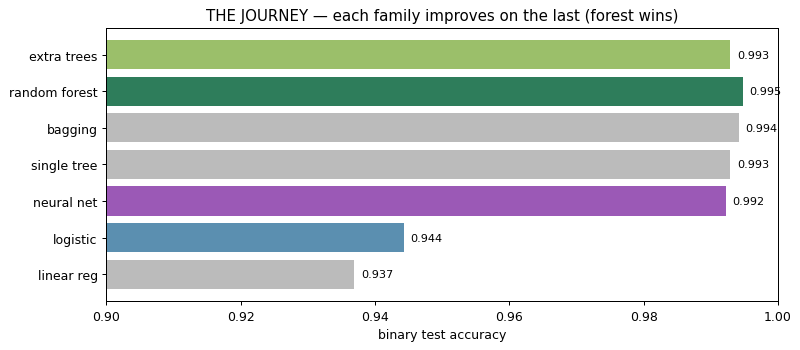

In [26]:
journey={'linear reg':accuracy_score(yte,(LinearRegression().fit(dtr[BASE],ytr).predict(dte[BASE])>0.5).astype(int)),
 'logistic':accuracy_score(yte,log_bin.predict(dte[BASE])),
 'neural net':accuracy_score(yte,make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'single tree':accuracy_score(yte,DecisionTreeClassifier(max_depth=12,random_state=0).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'bagging':accuracy_score(yte,BaggingClassifier(DecisionTreeClassifier(max_depth=12,random_state=0),n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'random forest':accuracy_score(yte,RandomForestClassifier(n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'extra trees':accuracy_score(yte,ExtraTreesClassifier(n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE]))}
fig,ax=plt.subplots(figsize=(9,4)); cols=['#bbb','#5B8FB0','#9b59b6','#bbb','#bbb','#2E7D5B','#9bbf6a']
ax.barh(list(journey),list(journey.values()),color=cols); ax.set_xlim(0.9,1.0)
ax.set(xlabel='binary test accuracy',title='THE JOURNEY — each family improves on the last (forest wins)')
for i,v in enumerate(journey.values()): ax.text(v+0.001,i,f'{v:.3f}',va='center',fontsize=9)
plt.tight_layout(); plt.show()

**Reading:** the climb from linear regression to the random forest on one chart. The forest tops it — and ties the neural net while staying interpretable and scaling-free.

### 7.2 The U2R fix — a cost-sensitive threshold (the finale)

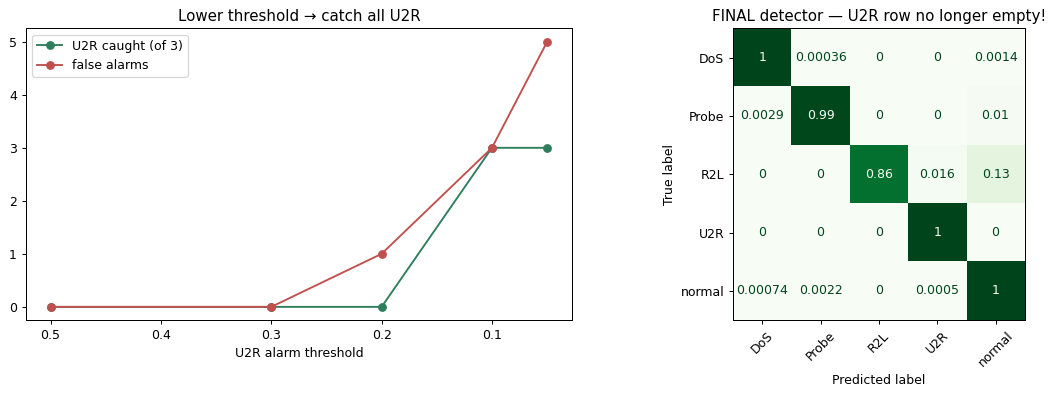

Final: accuracy 0.9951 | U2R recall 1.0


In [27]:
rf_u2r=RandomForestClassifier(n_estimators=300,random_state=0,n_jobs=-1,class_weight='balanced_subsample').fit(dtr_c[FEATURES],ytr_c)
ui=list(rf_u2r.classes_).index('U2R'); proba=rf_u2r.predict_proba(dte_c[FEATURES])[:,ui]; real=(yte_c=='U2R')
ths=[0.5,0.3,0.2,0.1,0.05]; caught=[int(((proba>=t)&real).sum()) for t in ths]; fa=[int(((proba>=t)&~real).sum()) for t in ths]
final=rf_u2r.predict(dte_c[FEATURES]).astype(object); final[proba>=0.1]='U2R'
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].plot(ths,caught,'o-',color='#2E7D5B',label=f'U2R caught (of {real.sum()})'); ax[0].plot(ths,fa,'o-',color='#C0504D',label='false alarms'); ax[0].invert_xaxis()
ax[0].set(xlabel='U2R alarm threshold',title='Lower threshold → catch all U2R'); ax[0].legend()
ConfusionMatrixDisplay.from_predictions(yte_c,final,normalize='true',cmap='Greens',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('FINAL detector — U2R row no longer empty!'); plt.tight_layout(); plt.show()
print('Final: accuracy',round(accuracy_score(yte_c,final),4),'| U2R recall',round(classification_report(yte_c,final,output_dict=True,zero_division=0)['U2R']['recall'],2))

**Reading — the finale.** Flagging U2R whenever its probability clears 0.10 catches **every** U2R attack at the cost of a couple of false alarms — the U2R row finally lights up. First time across the whole project that the rarest, most dangerous attack is detected.

---

## Conclusion (for your presentation)
We explored the data (skew → log transform, imbalance), then climbed model families: **linear regression** (wrong shape) → **logistic** (~94%) → **neural net** (~99%) → **random forest** (~99.5%, the winner) → **explainable AI** (why it decides). Evaluated **honestly** on the separate `KDDTest+` it scores **~77%** (realistic for novel attacks). The final detector — a **random forest with a cost-sensitive U2R threshold** — is accurate, interpretable, scaling-free, and the only model that catches U2R. *Data rule: train and test never share rows; `KDDTrain` pairs with the separate `KDDTest`.*